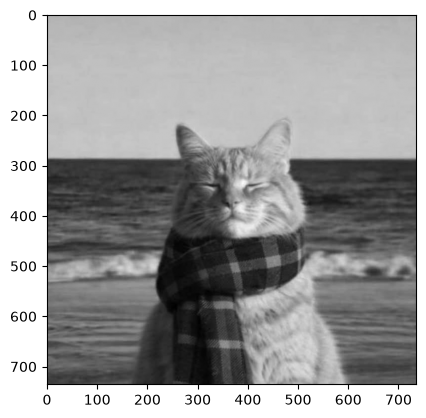

In [2]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
import copy
from skimage.metrics import structural_similarity, mean_squared_error

image = cv2.imread('img1.jpg')
image_gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

plt.imshow(image_gray,cmap = "gray")
plt.show()

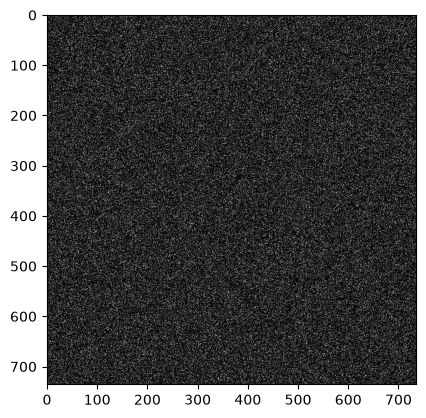

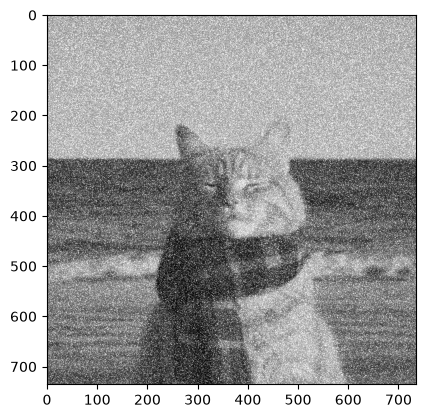

In [3]:
mean = 0
stddev = 100
noize_gauss =  np.zeros(image_gray.shape,np.uint8)
cv2.randn(noize_gauss, mean,stddev)
plt.imshow(noize_gauss, cmap ="gray")
plt.show()

image_ng = cv2.add(image_gray, noize_gauss)
plt.imshow(image_ng,cmap ="gray")
plt.show()

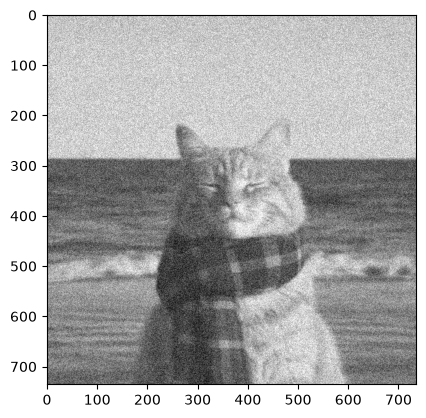

In [23]:
noise_uniform = np.random.randint(0, 100, size=image_gray.shape, dtype=np.uint8)
image_nu = cv2.add(image_gray, noise_uniform)

plt.imshow(image_noise_uniform, cmap="gray")
plt.show()

uniform + Median k = 3: MSE =  2677.9871071597354  SSIM =  0.29028852976302616


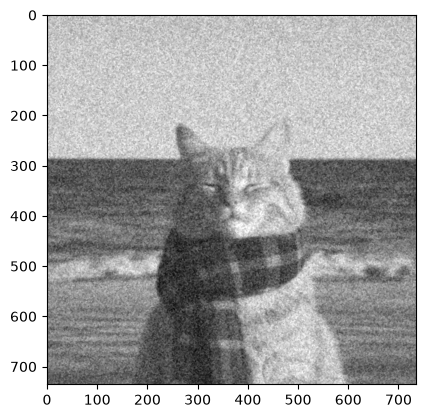

In [25]:
image_nu_m = cv2.medianBlur(image_nu,3)
mse_nu_m = mean_squared_error(image_gray,image_nu_m)
(ssim_nu_m, diff) = structural_similarity(image_gray,image_nu_m,full = True)
print("uniform + Median k = 3: MSE = ",mse_nu_m," SSIM = ", ssim_nu_m)
plt.imshow(image_nu_m, cmap="gray")
plt.show()

Uniform + Gausse k = 3: MSE =  2509.422218366021  SSIM =  0.5636926091426171


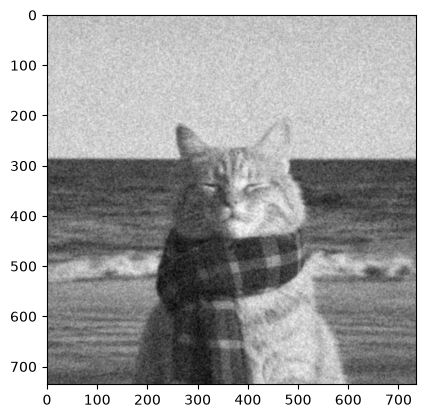

In [26]:
image_nu_g = cv2.GaussianBlur(image_nu, (5,5), 0)
mse_nu_g = mean_squared_error(image_gray, image_nu_g)
(ssim_nu_g, diff) = structural_similarity(image_gray,image_nu_g,full = True)
print("Uniform + Gausse k = 3: MSE = ",mse_nu_g," SSIM = ", ssim_nu_g)
plt.imshow(image_nu_g, cmap="gray")
plt.show()

Uniform + Bilateral:  MSE = 2487.8707319234404  SSIM = 0.6563892905716286


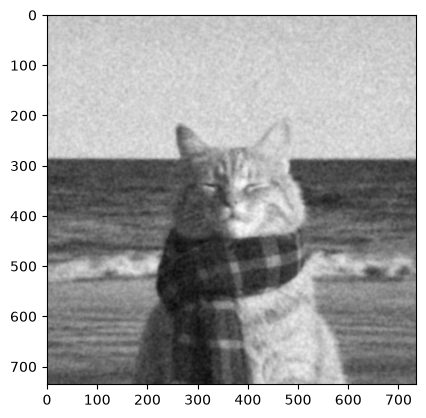

In [27]:
image_nu_b = cv2.bilateralFilter(image_nu, 9, 75, 75)
mse_nu_b = mean_squared_error(image_gray, image_nu_b)
(ssim_nu_b, diff) = structural_similarity(image_gray, image_nu_b, full=True)
print("Uniform + Bilateral:  MSE =", mse_nu_b, " SSIM =", ssim_nu_b)
plt.imshow(image_nu_b, cmap="gray")
plt.show()

Uniform + NLM h = 20:  MSE = 2507.7032819145793  SSIM = 0.5858797365158758


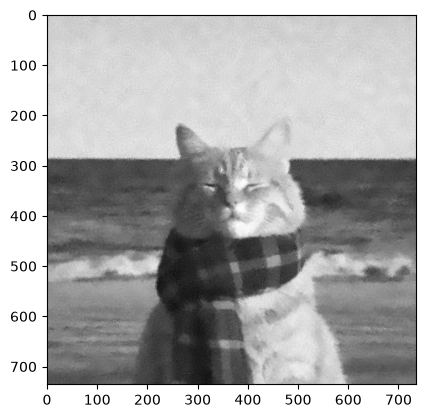

In [28]:
image_nu_nlm = cv2.fastNlMeansDenoising(image_nu, h=20)
mse_nu_nlm = mean_squared_error(image_gray, image_nu_nlm)
(ssim_nu_nlm, diff) = structural_similarity(image_gray, image_nu_nlm, full=True)
print("Uniform + NLM h = 20:  MSE =", mse_nu_nlm, " SSIM =", ssim_nu_nlm)
plt.imshow(image_nu_nlm, cmap="gray")
plt.show()

Uniform + NLM h = 20:  MSE = 2496.893047022684  SSIM = 0.7645169146408883


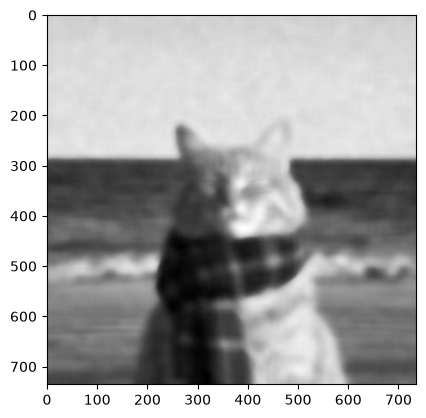

In [29]:
image_nu_nlm = cv2.fastNlMeansDenoising(image_nu, h=100)
mse_nu_nlm = mean_squared_error(image_gray, image_nu_nlm)
(ssim_nu_nlm, diff) = structural_similarity(image_gray, image_nu_nlm, full=True)
print("Uniform + NLM h = 20:  MSE =", mse_nu_nlm, " SSIM =", ssim_nu_nlm)
plt.imshow(image_nu_nlm, cmap="gray")
plt.show()

Uniform + NLM h = 20:  MSE = 2478.6859825437145  SSIM = 0.7822523227808688


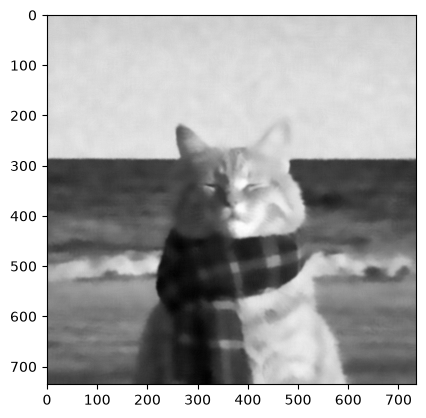

In [30]:
image_nu_nlm = cv2.fastNlMeansDenoising(image_nu, h=30)
mse_nu_nlm = mean_squared_error(image_gray, image_nu_nlm)
(ssim_nu_nlm, diff) = structural_similarity(image_gray, image_nu_nlm, full=True)
print("Uniform + NLM h = 20:  MSE =", mse_nu_nlm, " SSIM =", ssim_nu_nlm)
plt.imshow(image_nu_nlm, cmap="gray")
plt.show()

In [33]:
print("Для равномерного шума лучше NLM с параметром h = 30, шум почти полностью убрался")

Для равномерного шума лучше NLM с параметром h = 30, шум почти полностью убрался


Gauss + Median k=3: MSE =  829.3252820770322  SSIM =  0.20668959715723664


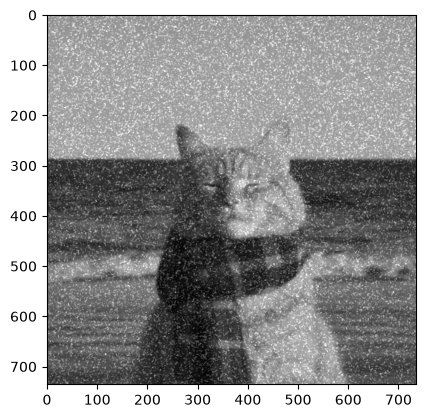

In [8]:
image_ng_m = cv2.medianBlur(image_ng,3)
mse_ng_m = mean_squared_error(image_gray,image_ng_m)
(ssim_ng_m, diff) = structural_similarity(image_gray,image_ng_m, full = True)
print("Gauss + Median k=3: MSE = ", mse_ng_m, " SSIM = ", ssim_ng_m)
plt.imshow(image_ng_m, cmap="gray")
plt.show()

Gauss + GAuss k = 3: MSE =  1417.7123829601844  SSIM =  0.38913712338335027


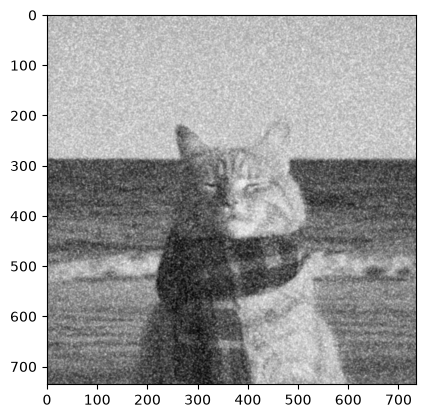

In [9]:
image_ng_g = cv2.GaussianBlur(image_ng, (5,5), 0)
mse_ng_g = mean_squared_error(image_gray, image_ng_g)
(ssim_ng_g, diff) = structural_similarity(image_gray,image_ng_g,full = True)
print("Gauss + GAuss k = 3: MSE = ",mse_ng_g," SSIM = ", ssim_ng_g)
plt.imshow(image_ng_g, cmap="gray")
plt.show()

Gausse + Bilateral:  MSE = 1374.8195814626654  SSIM = 0.26006191094089653


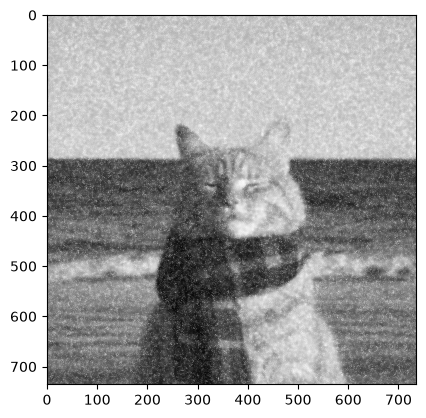

In [10]:
image_ng_b = cv2.bilateralFilter(image_ng, 9, 75, 75)
mse_ng_b = mean_squared_error(image_gray, image_ng_b)
(ssim_ng_b, diff) = structural_similarity(image_gray, image_ng_b, full=True)
print("Gausse + Bilateral:  MSE =", mse_ng_b, " SSIM =", ssim_ng_b)
plt.imshow(image_ng_b, cmap="gray")
plt.show()

Gausse + Bilateral:  MSE = 1154.671712547259  SSIM = 0.656465589697936


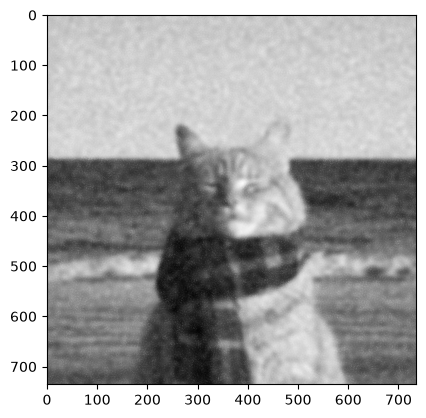

In [11]:
image_ng_b = cv2.bilateralFilter(image_ng, 15, 150, 150)
mse_ng_b = mean_squared_error(image_gray, image_ng_b)
(ssim_ng_b, diff) = structural_similarity(image_gray, image_ng_b, full=True)
print("Gausse + Bilateral:  MSE =", mse_ng_b, " SSIM =", ssim_ng_b)
plt.imshow(image_ng_b, cmap="gray")
plt.show()

Gauss + NLM h = 20:  MSE = 3308.6213337370036  SSIM = 0.05787624290520945


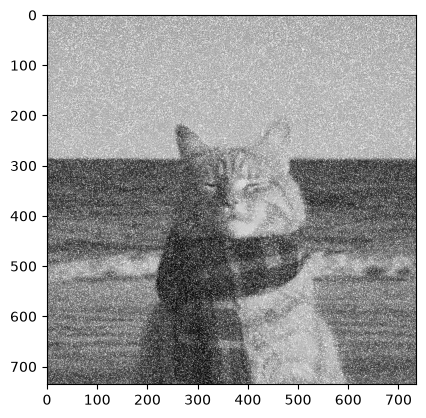

In [12]:
image_ng_nlm = cv2.fastNlMeansDenoising(image_ng, h=20)
mse_ng_nlm = mean_squared_error(image_gray, image_ng_nlm)
(ssim_ng_nlm, diff) = structural_similarity(image_gray, image_ng_nlm, full=True)
print("Gauss + NLM h = 20:  MSE =", mse_ng_nlm, " SSIM =", ssim_ng_nlm)
plt.imshow(image_ng_nlm, cmap="gray")
plt.show()

Gauss + NLM h = 100:  MSE = 1299.6933519907845  SSIM = 0.7804200050964685


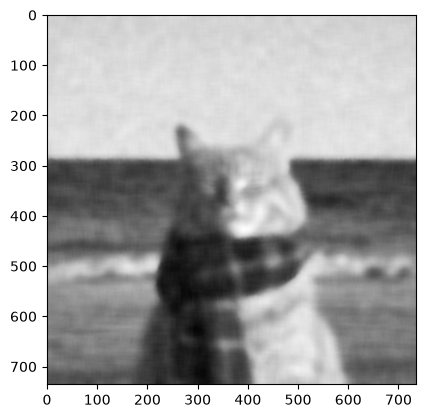

In [13]:
image_ng_nlm = cv2.fastNlMeansDenoising(image_ng, h=100)
mse_ng_nlm = mean_squared_error(image_gray, image_ng_nlm)
(ssim_ng_nlm, diff) = structural_similarity(image_gray, image_ng_nlm, full=True)
print("Gauss + NLM h = 100:  MSE =", mse_ng_nlm, " SSIM =", ssim_ng_nlm)
plt.imshow(image_ng_nlm, cmap="gray")
plt.show()

Gauss + NLM h = 30:  MSE = 1886.541488214792  SSIM = 0.3770877856791207


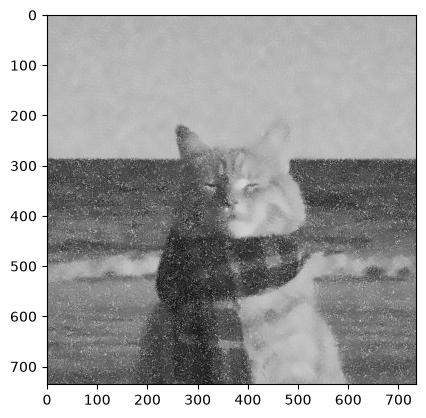

In [14]:
image_ng_nlm = cv2.fastNlMeansDenoising(image_ng, h=30)
mse_ng_nlm = mean_squared_error(image_gray, image_ng_nlm)
(ssim_ng_nlm, diff) = structural_similarity(image_gray, image_ng_nlm, full=True)
print("Gauss + NLM h = 30:  MSE =", mse_ng_nlm, " SSIM =", ssim_ng_nlm)
plt.imshow(image_ng_nlm, cmap="gray")
plt.show()

In [32]:
print("Для шума Гаусса лучшие NLM и Bilateral. NLM с параметром h = 100 лучше по SSIM, но размывает, Bilateral чуть хуже по SSIM, но сохраняет резкость")

Для шума Гаусса лучшие NLM и Bilateral. NLM с параметром h = 100 лучше по SSIM, но размывает, Bilateral чуть хуже по SSIM, но сохраняет резкость
